In [81]:
import numpy as np
import eplots
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
import matplotlib as mpl
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors
mpl.style.use(('/Users/eb35267/Desktop/mpl_style/pres_style.mplstyle', '/Users/eb35267/Desktop/mpl_style/estyle.mplstyle'))

Figures for seminar talk

#b84557
#03abc1
#d4d000
#294450
#bf5700
#719920
#8aa0ff


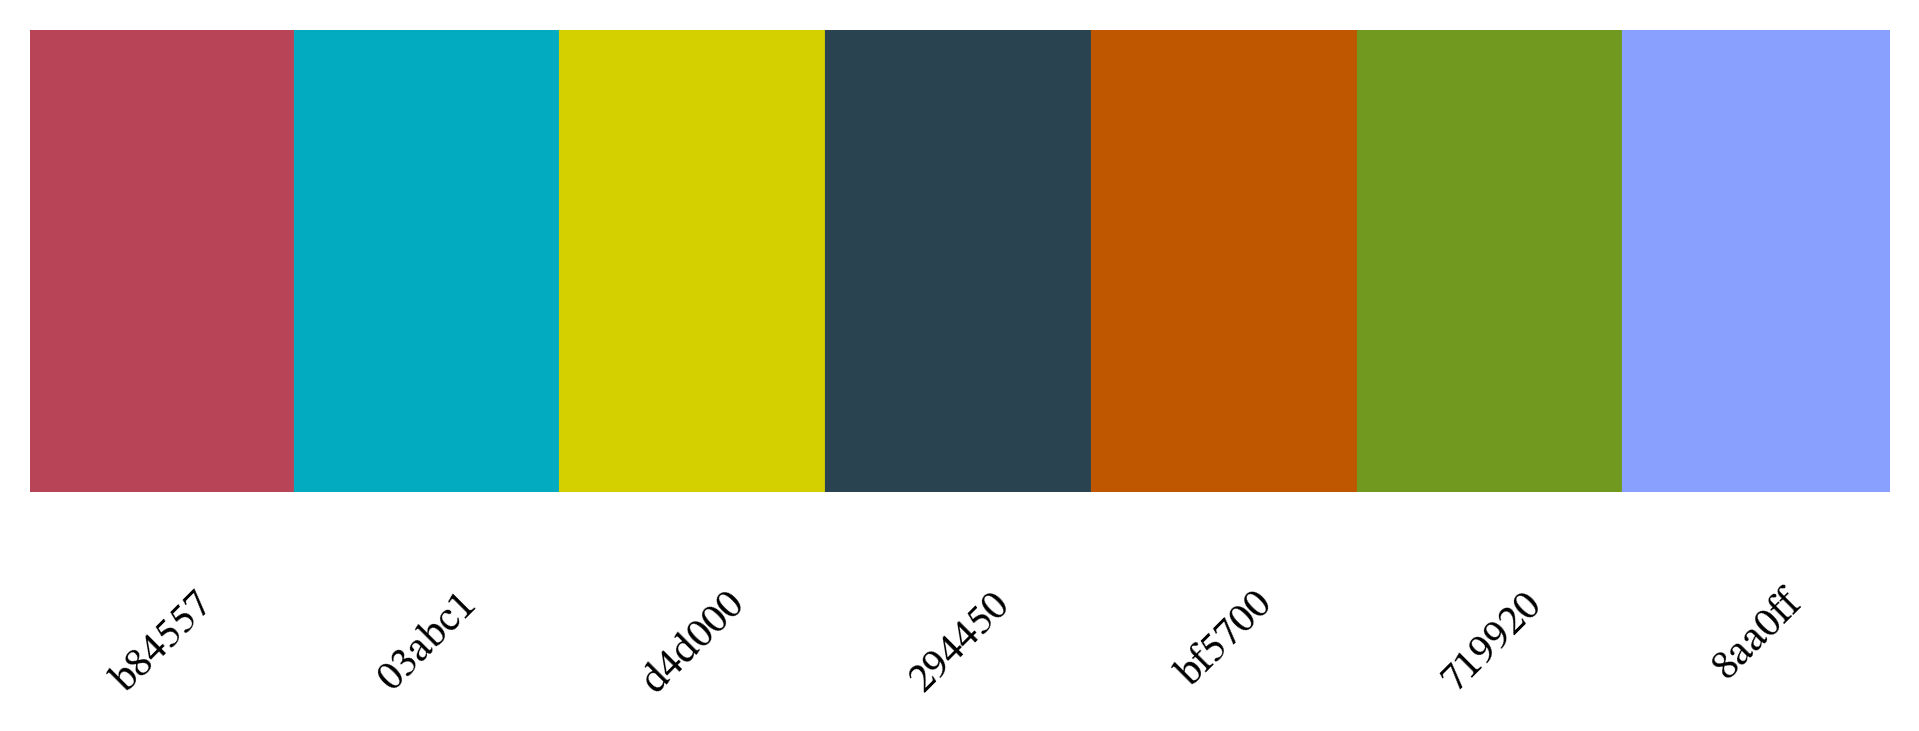

In [2]:
eplots.plot_colors()

In [82]:
def interpolate_color(hex1, hex2):
    """
    Interpolates between two hex colors.
    
    Parameters:
        hex1 (str): First color in hex format (e.g., '#FF0000' for red).
        hex2 (str): Second color in hex format (e.g., '#0000FF' for blue).
        t (float): Interpolation factor (0 gives hex1, 1 gives hex2, 0.5 is halfway).
    
    Returns:
        str: Interpolated color in hex format.
    """
    # Convert hex to RGB (values between 0 and 1)
    rgb1 = mcolors.hex2color(hex1)
    rgb2 = mcolors.hex2color(hex2)
    
    # Interpolate each RGB channel
    interp_rgb = [0.5* c1 + t * c2 for c1, c2 in zip(rgb1, rgb2)]
    
    # Convert back to hex
    return mcolors.to_hex(interp_rgb)

### Adapted Gelli+24 figure

In [3]:
line = np.array([8.006711409395972, 1.74390243902439,
12.48993288590604, 0.19918699186991873]).reshape(-1,2)

In [4]:
FIRE_z8 = np.array([9.201342281879194, 1.4024390243902438,
9.29530201342282, 1.3455284552845526,
9.375838926174497, 1.2723577235772354,
9.536912751677852, 1.215447154471545,
9.604026845637584, 1.2235772357723573,
9.711409395973154, 1.1097560975609753,
9.805369127516778, 0.98780487804878,
9.912751677852349, 1.0040650406504064,
9.993288590604028, 1.0365853658536581,
10.221476510067113, 0.98780487804878,
10.409395973154362, 0.9715447154471546,
10.59731543624161, 0.98780487804878,
10.798657718120804, 0.7520325203252032,
11, 0.5650406504065035,
11.093959731543624, 0.6219512195121952,
11.201342281879194, 0.7601626016260159]).reshape(-1,2)

FIRE_z10 = np.array([9.496644295302012, 1.3048780487804876,
9.577181208053691, 1.1585365853658534,
9.791946308724832, 1.0203252032520327,
10.006711409395972, 1.1829268292682924,
10.181208053691275, 1.0040650406504064,
10.59731543624161, 0.7764227642276422,
10.691275167785236, 0.678861788617886,
10.798657718120804, 0.6056910569105689,
10.919463087248321, 0.6382113821138207,
10.986577181208052, 0.6707317073170733,
11.120805369127517, 0.6626016260162597,
11.201342281879194, 0.630081300813008,
9.402684563758388, 1.434959349593496,
9.281879194630871, 1.5,
9.187919463087248, 1.5325203252032522]).reshape(-1,2)
FIRE_z10=FIRE_z10[np.argsort(FIRE_z10[:,0])]

FIRE_z12=np.array([9.201342281879194, 1.5325203252032522,
9.308724832214764, 1.5162601626016259,
9.389261744966444, 1.3943089430894307,
9.496644295302012, 1.3292682926829267,
9.590604026845638, 1.2967479674796745,
9.765100671140939, 1.142276422764228,
9.939597315436242, 1.0203252032520327,
10.006711409395972, 0.9715447154471546,
10.12751677852349, 0.9796747967479673,
10.194630872483222, 0.98780487804878,
10.315436241610737, 0.9065040650406502,
10.409395973154362, 0.8414634146341466,
10.59731543624161, 0.46747967479674735,
10.78523489932886, 0.296747967479674,
10.892617449664428, 0.16666666666666696]).reshape(-1,2)

In [74]:
# Custom legend handler
class HandlerStackedLine(HandlerLine2D):
    def __init__(self, colors, *args, **kwargs):
        self.colors = colors[::-1] # Make the list go the opposite direction
        super().__init__(*args, **kwargs)
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        return [Line2D([xdescent, xdescent + width], [ydescent + i * 10] * 2, color=self.colors[i], transform=trans)
                for i in range(len(self.colors))]

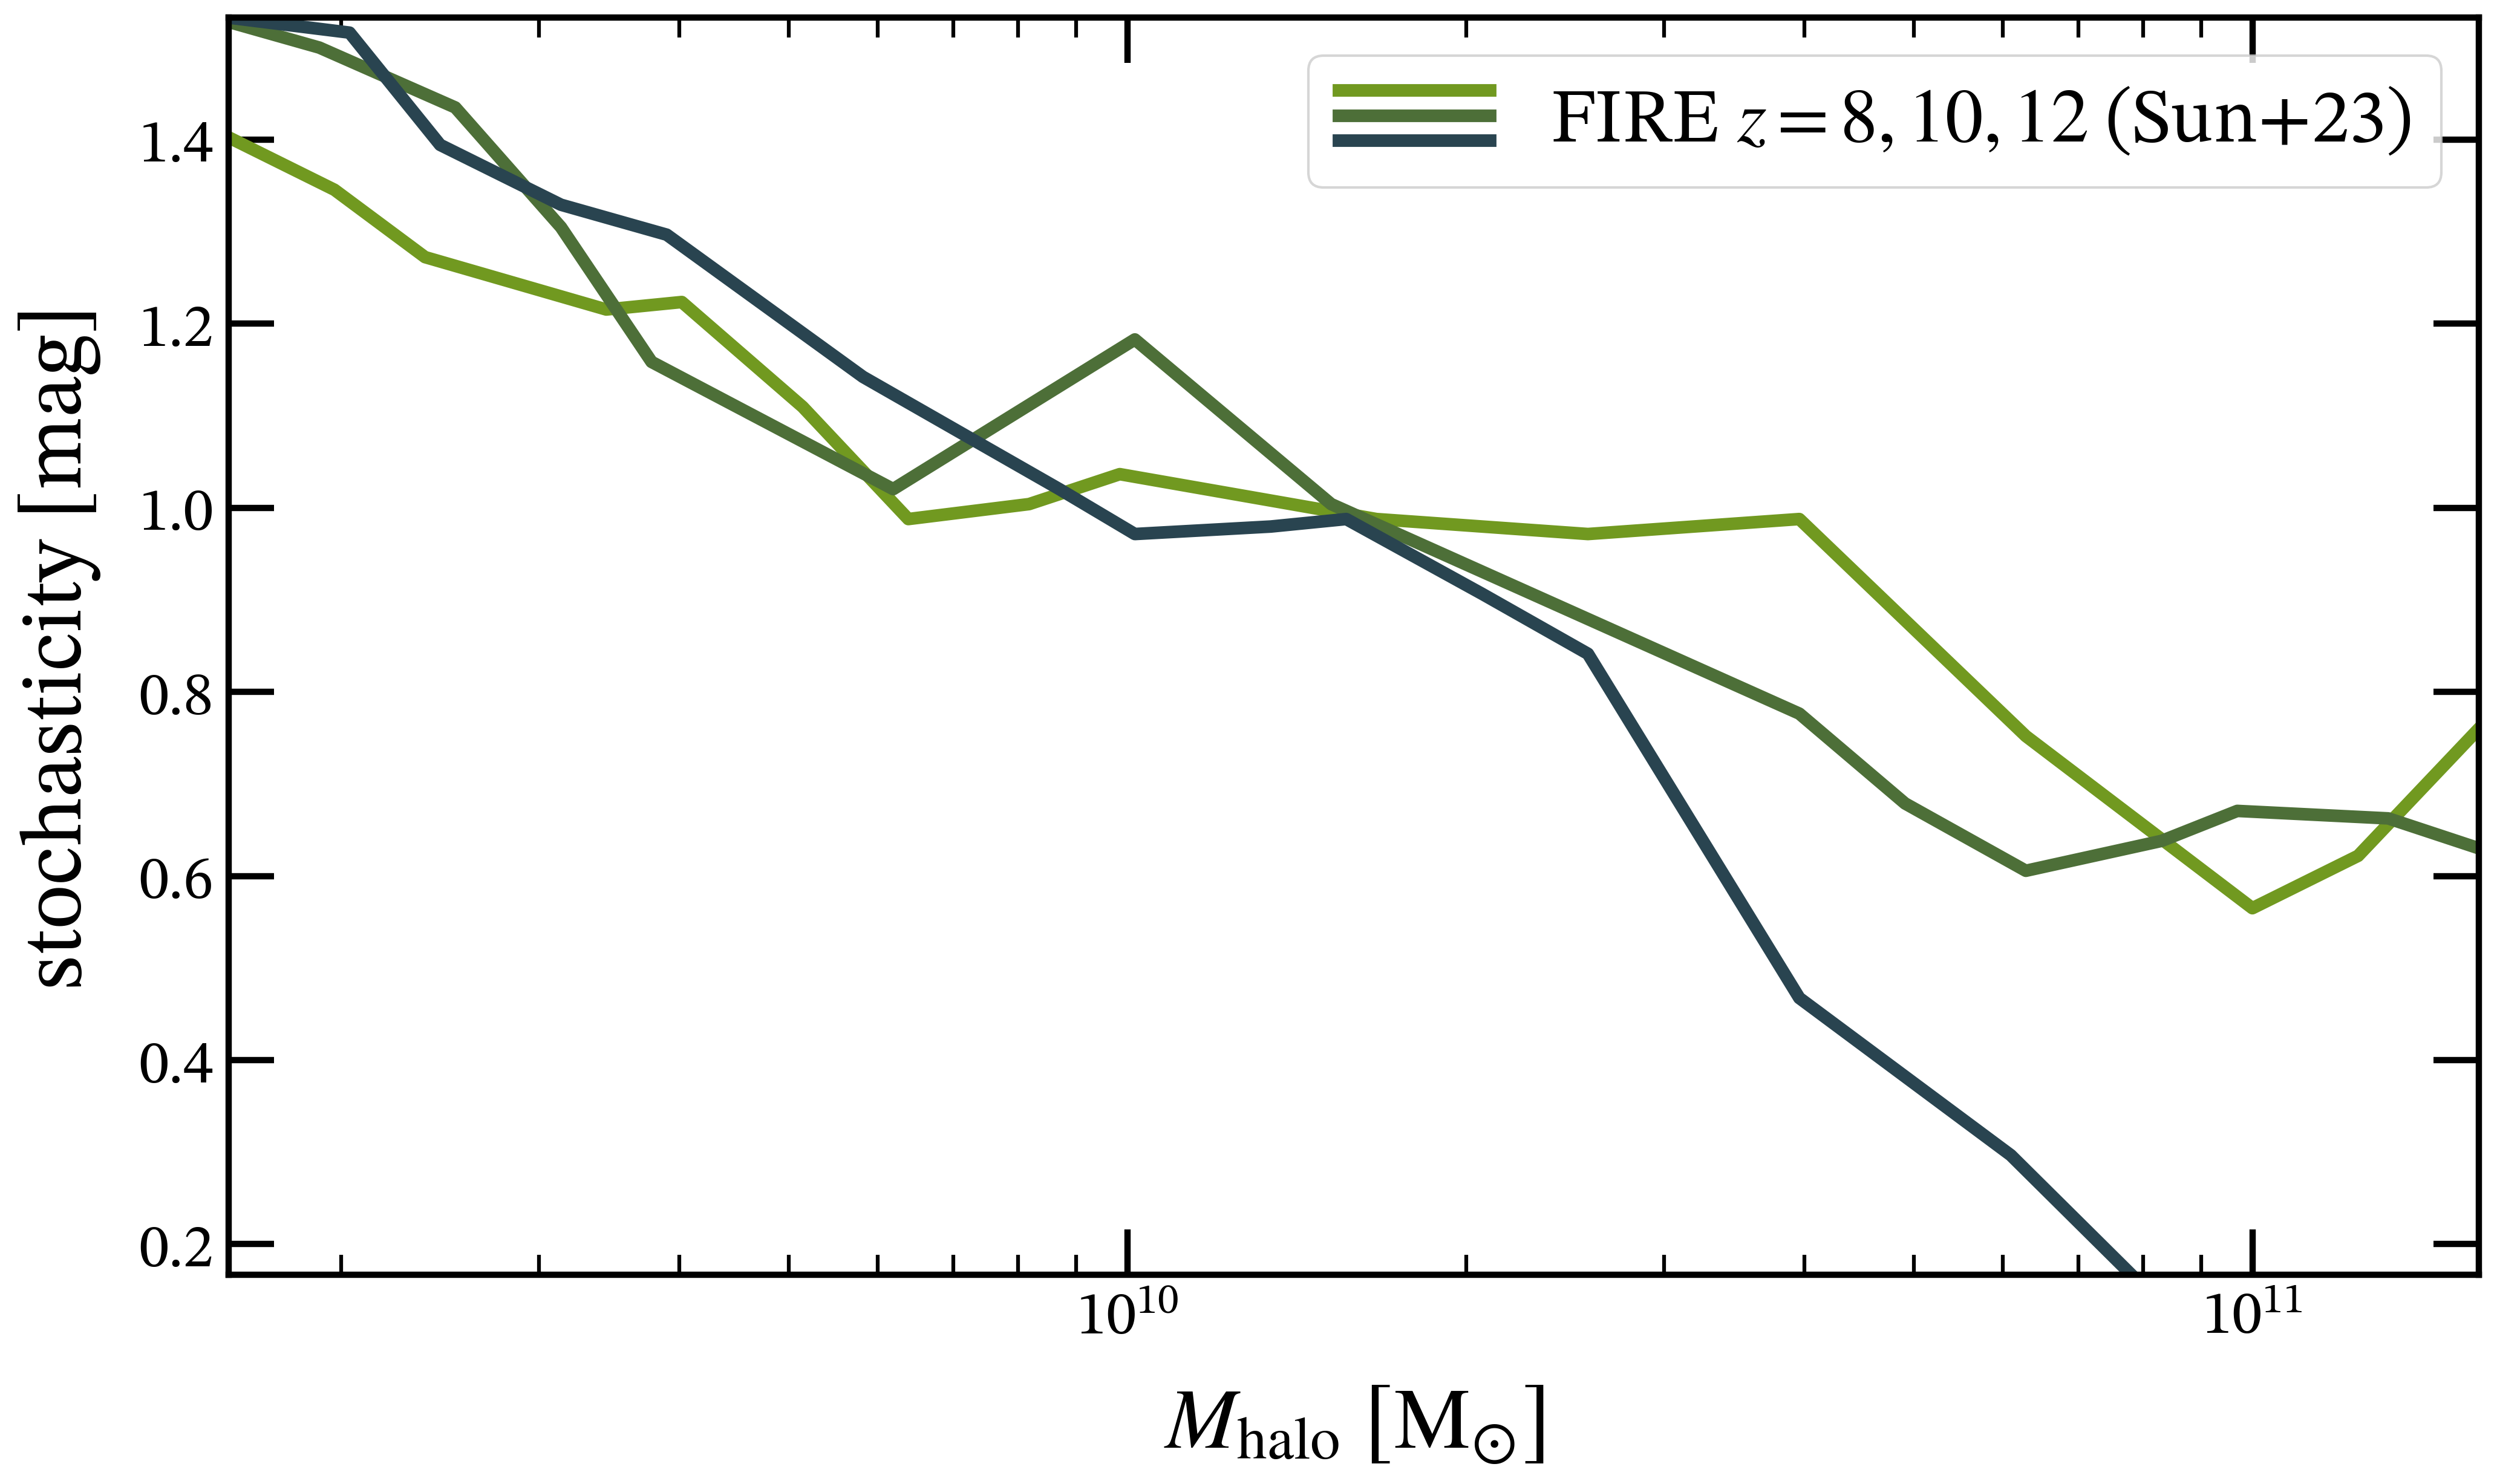

In [97]:
fig, ax = plt.subplots()
FIRE_colors = ['#719920', '#4D6F38', '#294450']
Gelli_color = '#03abc1'
ax.plot(10**FIRE_z8[:,0], FIRE_z8[:,1], color=FIRE_colors[0], label = r'FIRE $z=8$')
ax.plot(10**FIRE_z10[:,0], FIRE_z10[:,1], color = FIRE_colors[1], label = r'FIRE $z=10$')
ax.plot(10**FIRE_z12[:,0], FIRE_z12[:,1], color = FIRE_colors[2], label = r'FIRE $z=12$')
#ax.plot(10**line[:,0], line[:,1], color = Gelli_color, label = r'Gelli+24 (all $z$)', linestyle = '--')
ax.set_xlim((10**FIRE_z8[:,0][0], 10**FIRE_z8[:,0][-1]))
ax.set_ylim((FIRE_z12[:,1][-1], FIRE_z12[:,1][0]))

ax.set_xscale('log')
FIRE_lines = Line2D([], [])
Gelli_line = Line2D([0], [0], color=Gelli_color, linestyle = '--')
ax.legend(
    [FIRE_lines, Gelli_line],  # Legend handles
    [r'FIRE $z=8, 10, 12$ (Sun+23)'],
    #[r'FIRE $z=8, 10, 12$ (Sun+23)', r'Gelli+24 (all $z$)'], # Corresponding labels
    handler_map={FIRE_lines: HandlerStackedLine(FIRE_colors)}  # Applying custom handler only to Line2D
)

ax.set_ylabel(r'stochasticity [mag]')
ax.set_xlabel(r'$M_{\rm{halo}}$ [$\rm{M}_{\odot}$]')

#fig.savefig('/Users/eb35267/Desktop/figures/adapted figures/FIRE_stochasticity_dependence.png', bbox_inches='tight')

### Shen+23 Figure

In [9]:
# Theoretical curve
# Theoretical curve
curve = np.array([-16.091627152579992, -2.215513631389835,
-16.275905849119567, -2.3625789829035284,
-16.447025772755847, -2.497396338576872,
-16.55232389392893, -2.5831770101740688,
-16.776134785071825, -2.742579758957604,
-16.920909224954794, -2.8651044180758514,
-17.052552829881186, -2.9631777862281443,
-17.26317701017407, -3.122535834296934,
-17.65796813521966, -3.477772414381834,
-17.78958380219934, -3.5880490776597314,
-17.960647849942184, -3.7472730235842833,
-18.131683959738314, -3.9187002646344395,
-18.38170064490094, -4.151412185601092,
-18.63166145417013, -4.408530696818954,
-18.80269756396626, -4.579957937869111,
-18.921098582149206, -4.702393195557867,
-19.09210675399862, -4.886023731733627,
-19.368273357287535, -5.216451415134607,
-19.47348766462047, -5.338841972108616,
-19.618150352716576, -5.510179811729281,
-19.736523432952808, -5.644818364543641,
-19.868027348145617, -5.803908208323955,
-19.973185779585123, -5.950705355549175,
-20.196661415367423, -6.256547645839962,
-20.328137392613517, -6.427840784745881,
-20.485875039772772, -6.648036505583709,
-20.604164306168855, -6.819284943774883,
-20.748659366584665, -7.063842554149174,
-20.84065902512087, -7.198391705534041,
-20.97210706442025, -7.3818881395655636,
-21.142863794749218, -7.675348331871765,
-21.32672342208805, -8.005463110269524]).reshape(-1, 2)
curve[:,1] = 10**curve[:,1] # Take out of logspace

phot_z = np.array([-17.3, -2.87,
-18.3, -3.21,
-17.9, -3.70,
-18.2, -3.86,
-18.3, -3.48,
-18.9, -3.63,
-18.9, -3.79,
-18.8, -3.74,
-19.6, -4.03,
-20.1, -4.12,
-19.2, -4.63,
-19.0, -4.57,
-20.1, -4.43,
-20.0, -4.51,
-20.2, -4.90,
-20.3, -4.71,
-20.4, -5.00,
-20.8, -4.92,
-21.0, -5.01,
-21.0, -5.47,
-21.2, -5.32,
-21.8, -5.91,
-22.2, -5.21,
-23.2, -5.25,
-22.6, -6.95,
-23.5, -7.46
]).reshape(-1,2)
phot_z[:,0], phot_z[:,1] = phot_z[:,0][np.argsort(phot_z[:,0])], 10**phot_z[:,1][np.argsort(phot_z[:,0])] # Take out of logspace, order

# Spectroscopically confirmed sources
spec_z = np.array([-18.711256664364374, -4.2013428839721545,
-20.107064420248804, -5.072515113653119,
-23.504849561917474, -6.999965232777419
]).reshape(-1, 2)
spec_z[:,1] = 10**spec_z[:,1] # Take out of logspace
# Error on those sources
yerr_lower = spec_z[:,1] - 10**np.array([-4.72, -5.51, -7.38])
yerr_upper = 10**np.array([-3.81, -4.67, -6.9]) - spec_z[:,1]
yerr = [yerr_lower, yerr_upper]

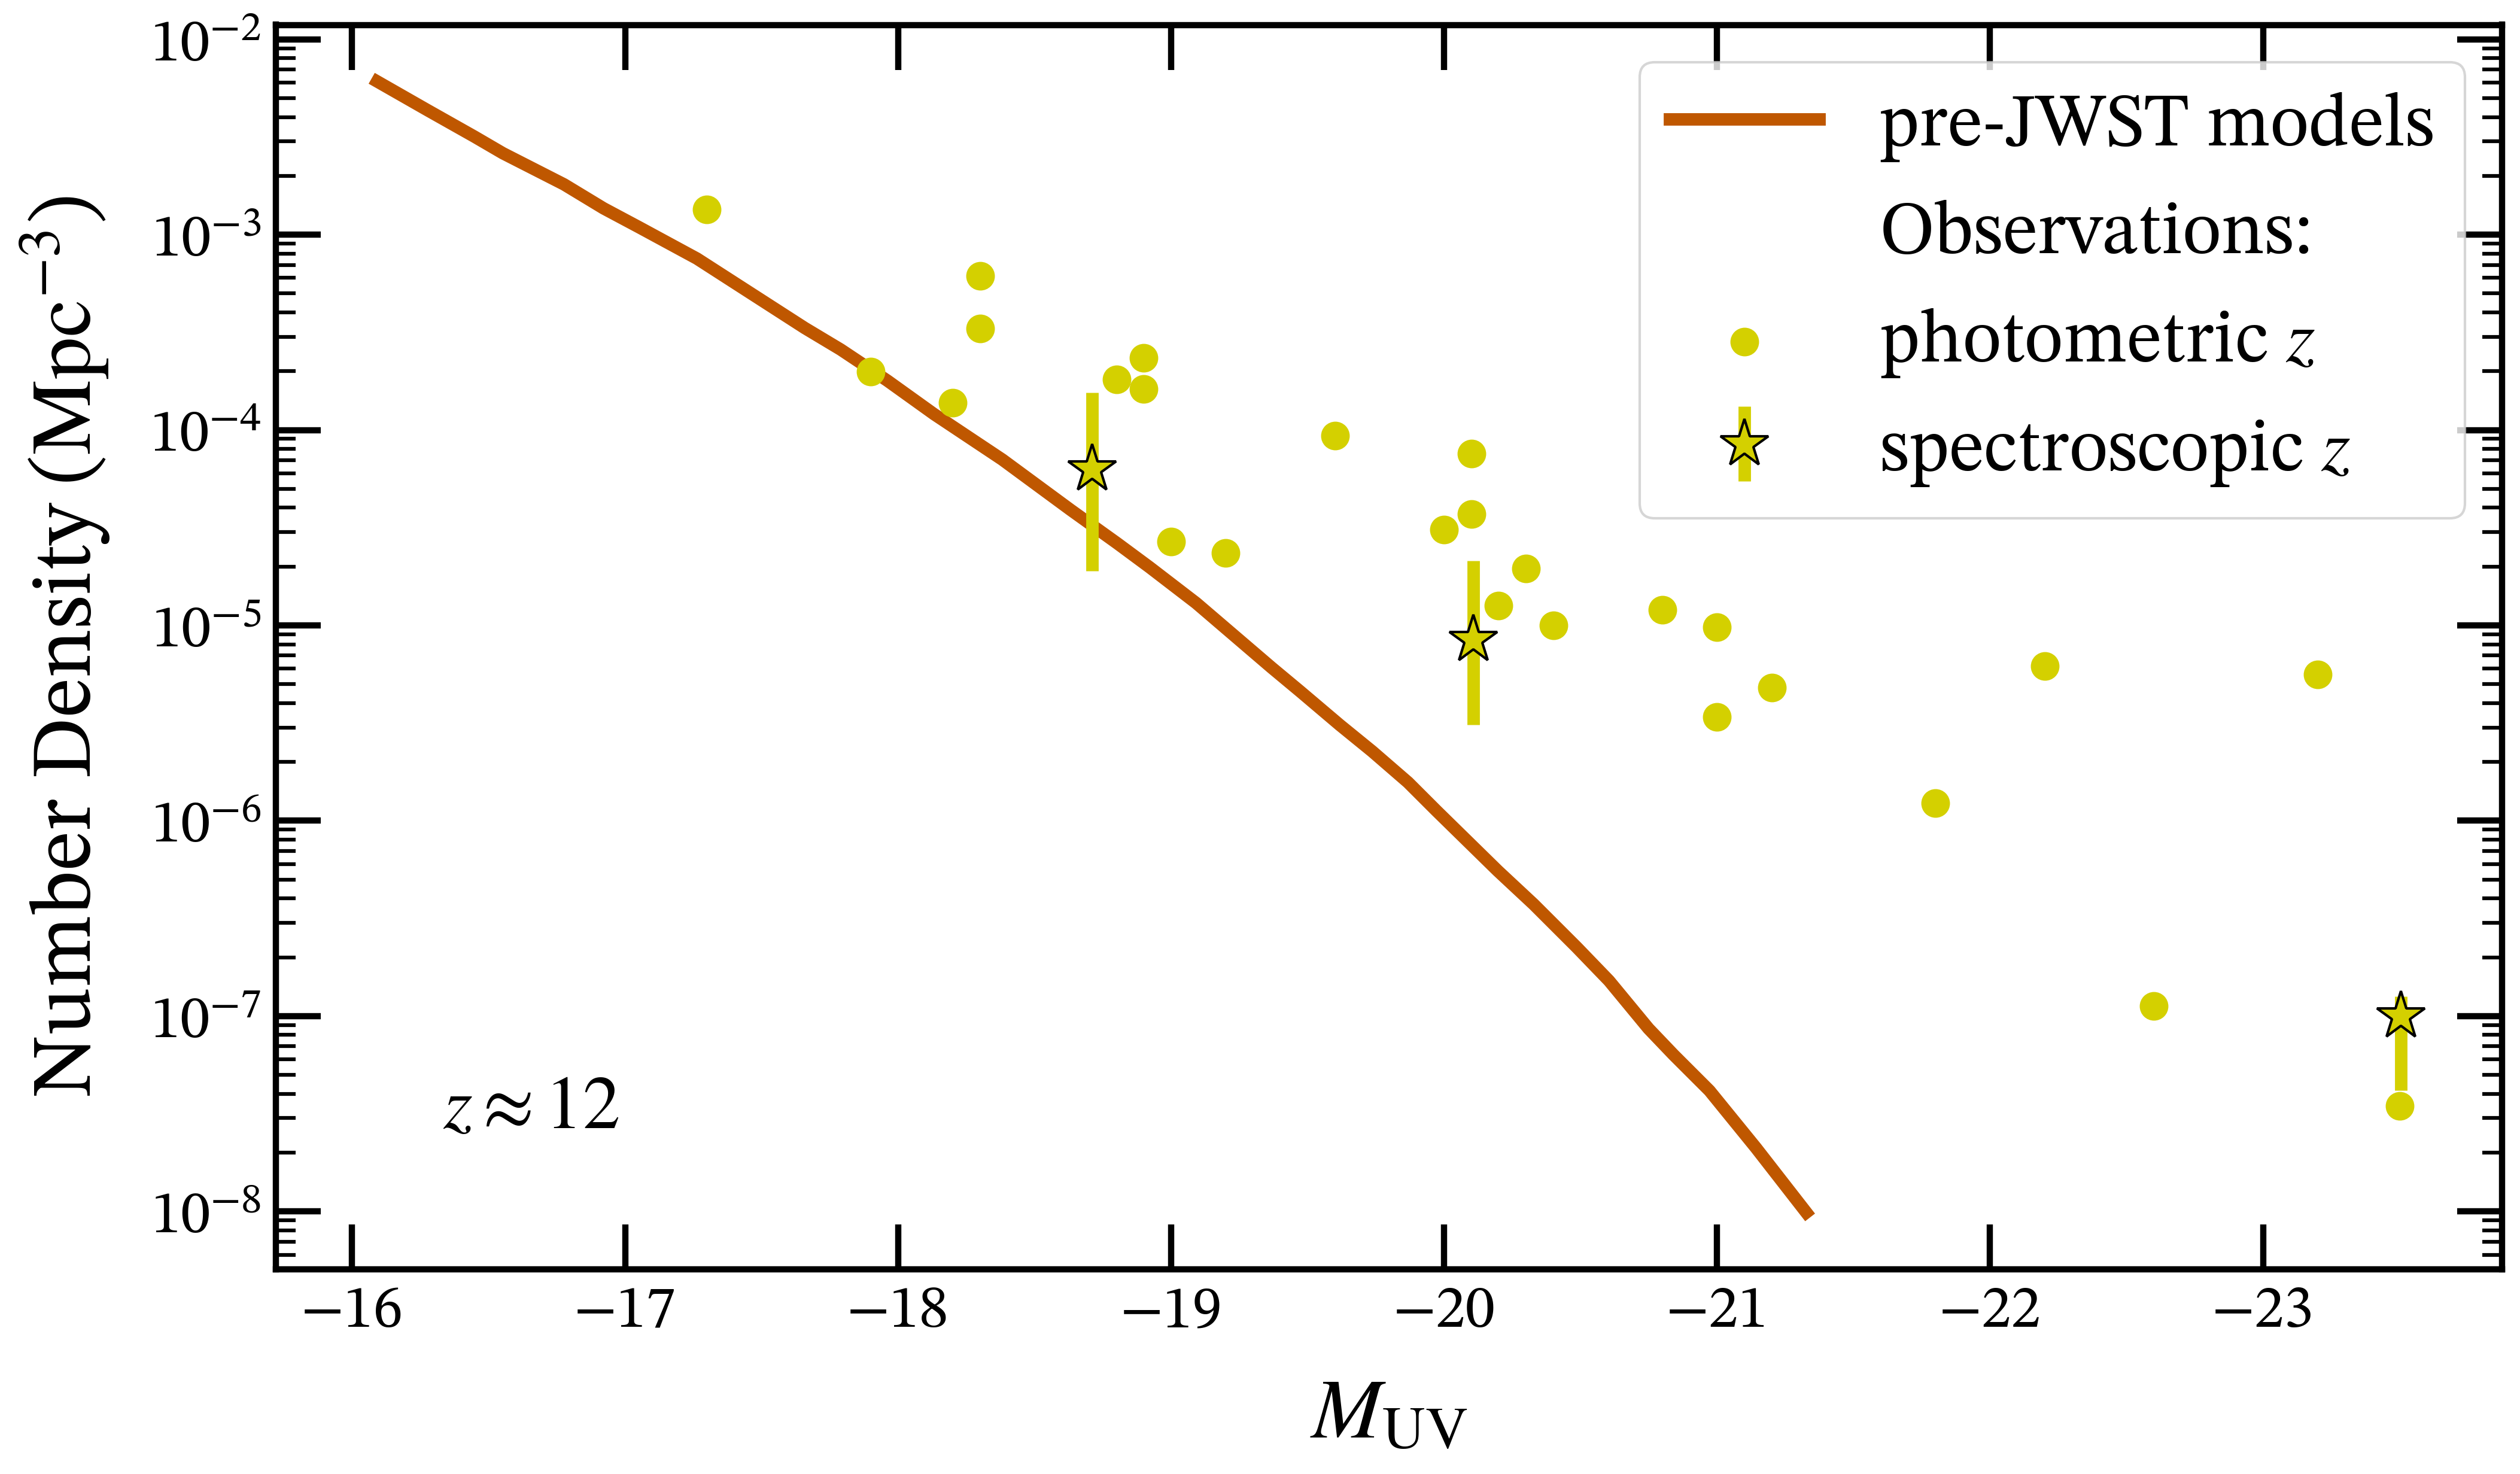

In [27]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.plot(curve[:,0], curve[:,1], label = 'pre-JWST models', zorder = 0, color = '#bf5700')
plt.plot([], [], ' ', color = 'None', label = 'Observations:')
ax.errorbar(*spec_z.T, yerr = yerr, fmt = '*', label = r'spectroscopic $z$', color = '#d4d000', markersize=20)
ax.scatter(*phot_z.T, label = r'photometric $z$', s=110, color = '#d4d000')

ax.set_ylabel(r'Number Density ($\rm{Mpc}^{-3}$)')
ax.set_xlabel(r'$M_{\rm{UV}}$')
plt.text(0.075, 0.1, r'$z\approx12$', transform=plt.gca().transAxes, verticalalignment='bottom', horizontalalignment='left')

plt.gca().invert_xaxis()
ax.set_yscale('log')
ax.legend()

#fig.savefig('/Users/eb35267/Desktop/figures/adapted figures/bright_galaxy_tension.png', bbox_inches = 'tight')

### Fitting figure

In [13]:
def f(x, a, x0, b):
# def f(x, a, x0, b, c):
    # return a*(x/x0)**b/(1+(x/x0))**c
    return a/(1+(x/x0))**b

In [14]:
p0 = [-1, -21, -1]
bounds = (
    (-np.inf,  -22,  -np.inf),   # Lower bounds (ensuring b > 1 makes it concave
    (np.inf, -18, 1)  # Upper bounds
)
# bounds = [[-np.inf, -22, -np.inf, -np.inf],[np.inf, -18, np.inf, np.inf]]
popt, _ = curve_fit(f, np.concatenate((np.tile(spec_z[:,0],4), phot_z[:,0])), 
                    np.concatenate((np.log(np.tile(spec_z[:,1], 4)), np.log(phot_z[:,1]))), p0, 
                    maxfev = int(1e6), bounds = bounds) # Use tile to weight the spectroscopic observation more heavily
                    # Use log since we're plotting in exponential/regular space.

In [15]:
popt

array([ -0.35813728, -18.00000118,  -4.54033989])

In [16]:
np.exp(f(phot_z[:,0], *popt))

array([1.25390733e-07, 2.09851122e-07, 5.65239666e-07, 1.06384100e-06,
       1.95890962e-06, 4.70345506e-06, 6.23333764e-06, 6.23333764e-06,
       8.21909223e-06, 1.40780624e-05, 1.60561606e-05, 1.82900608e-05,
       2.08097421e-05, 2.08097421e-05, 2.36482940e-05, 3.89777499e-05,
       6.30684683e-05, 7.96836708e-05, 8.94178716e-05, 8.94178716e-05,
       1.00230841e-04, 1.74514599e-04, 1.74514599e-04, 1.94361201e-04,
       2.66823587e-04, 4.89218799e-04])

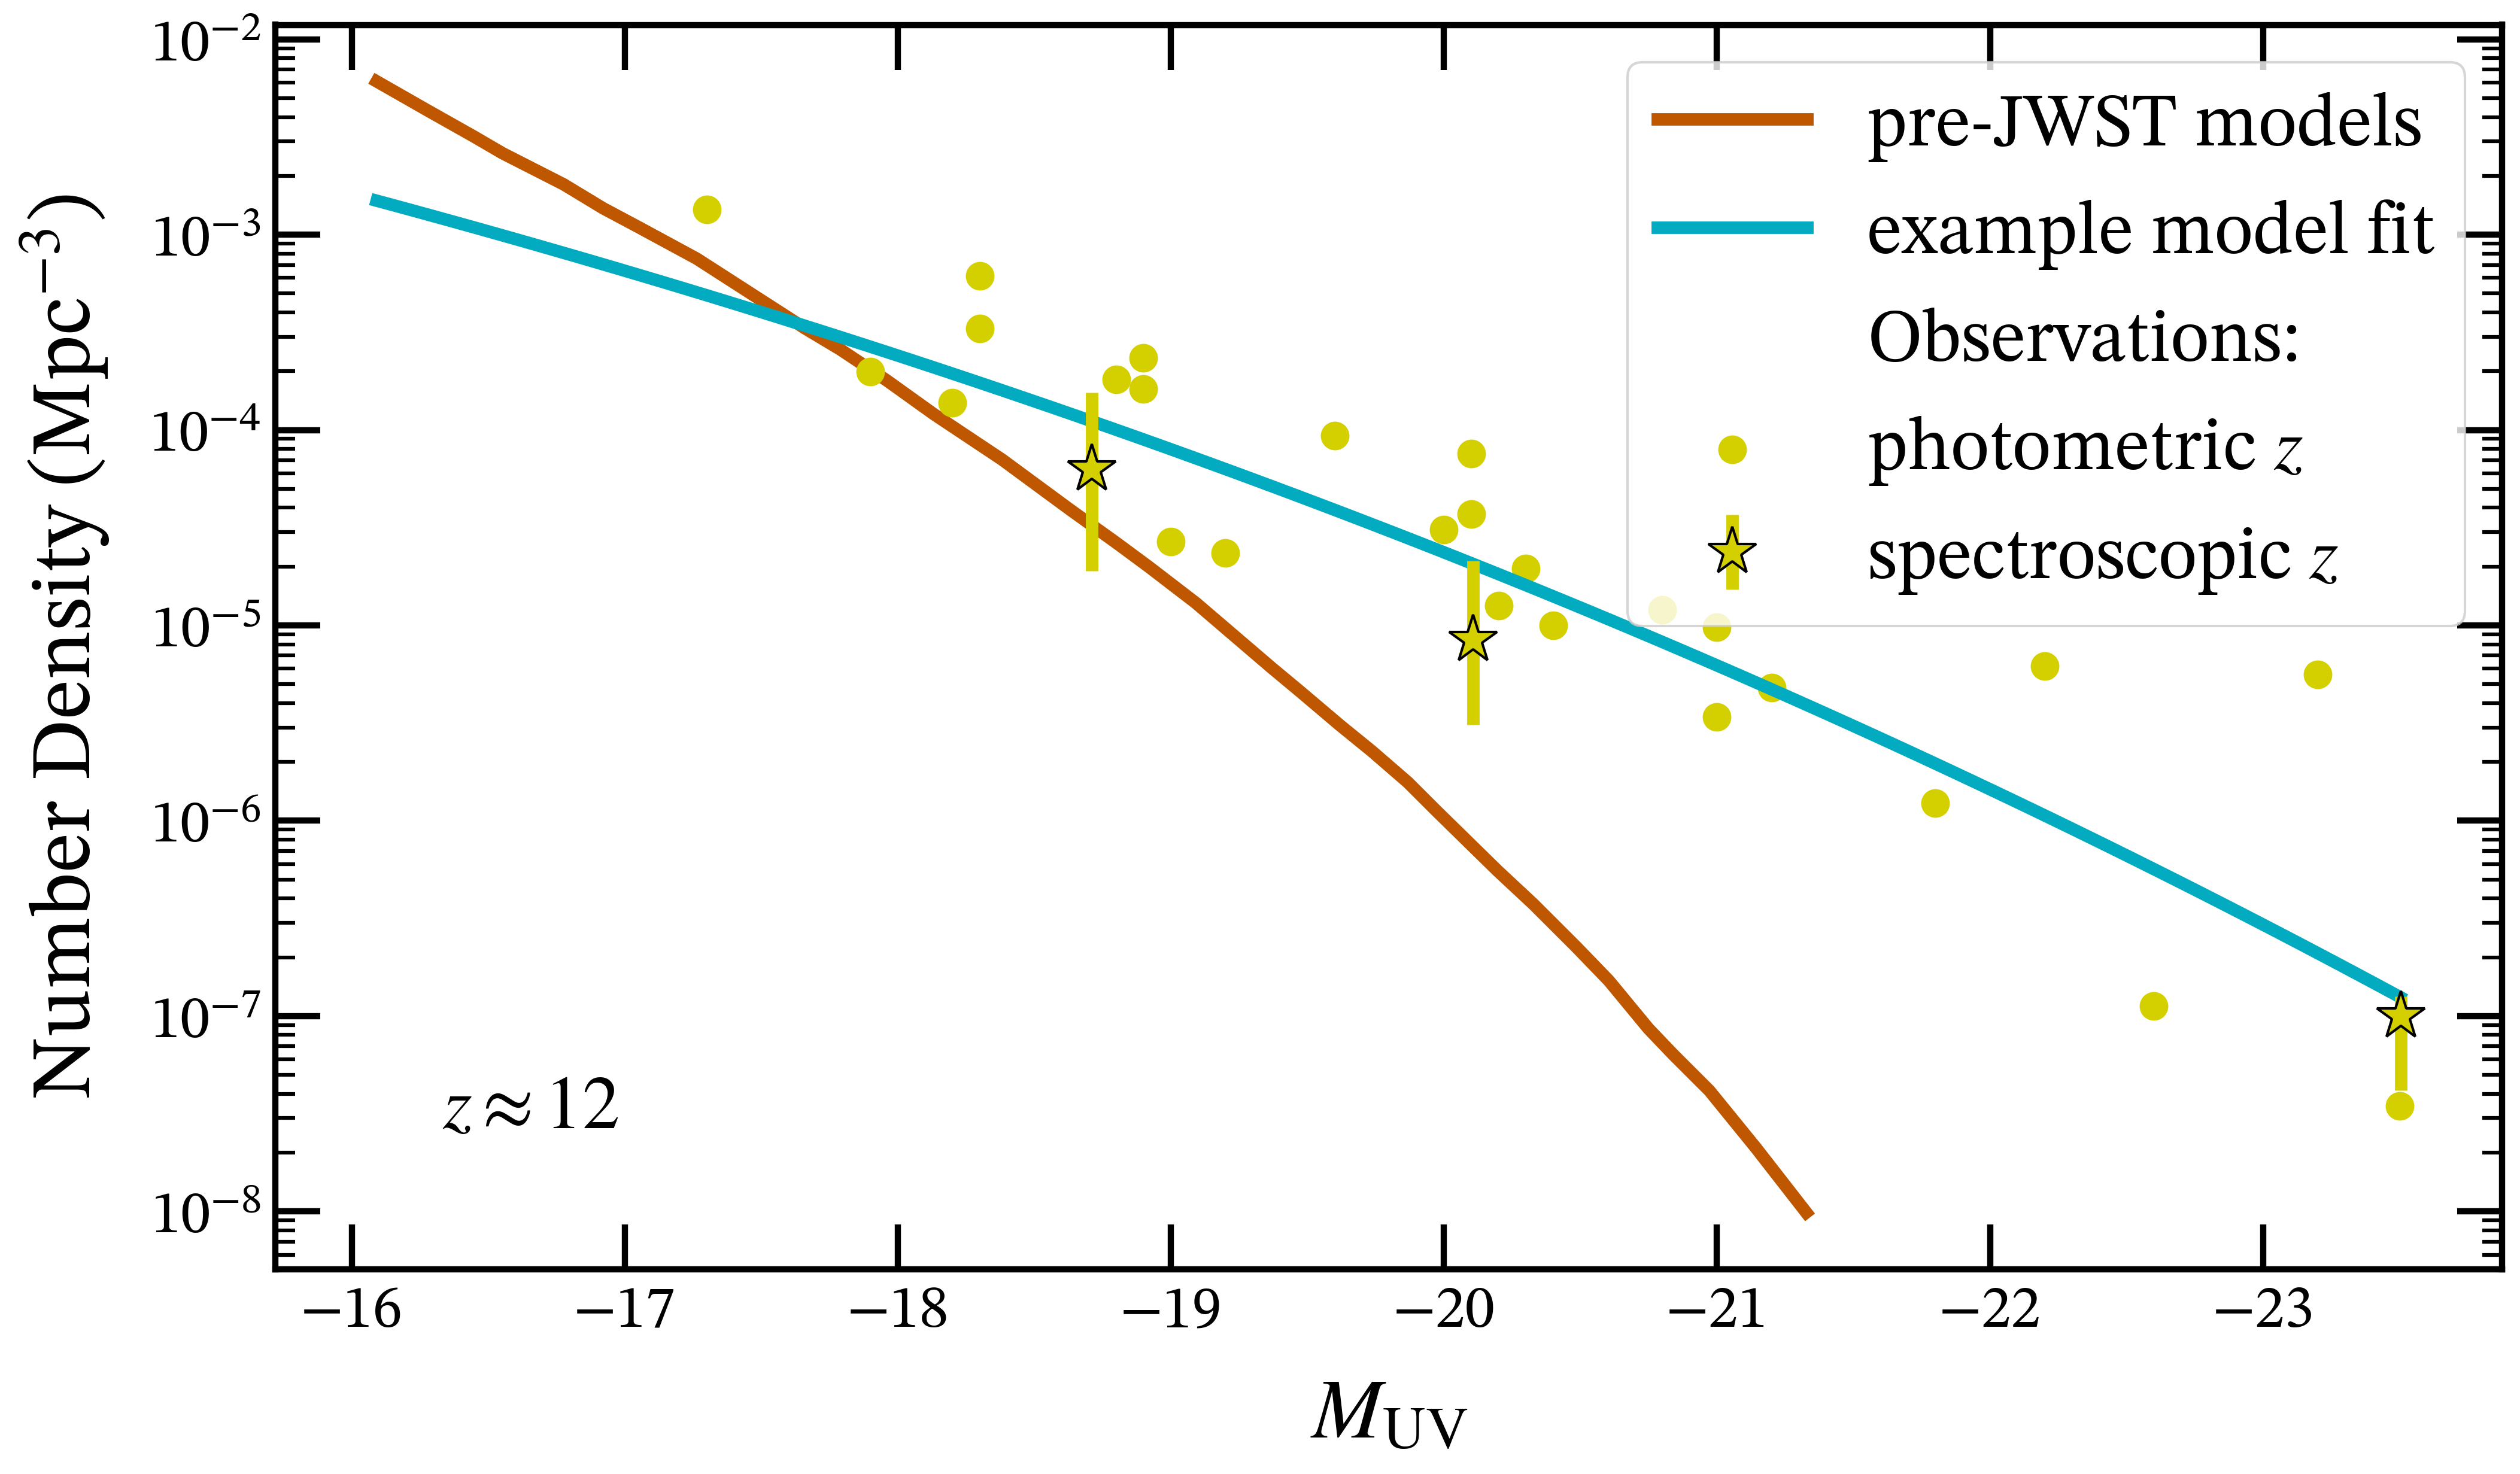

In [28]:
# Plot
fig, ax = plt.subplots()

x_vals = np.linspace(curve[:,0][0], -23.5, 100)
ax.plot(curve[:,0], curve[:,1], label = 'pre-JWST models', zorder = 0, color = '#bf5700')
ax.plot(x_vals, np.exp(f(x_vals, *popt)), label = 'example model fit', color = '#03abc1')
plt.plot([], [], ' ', color = 'None', label = r'Observations:')
ax.errorbar(*spec_z.T, yerr = yerr, fmt = '*', label = r'spectroscopic $z$', color = '#d4d000', markersize = 20)
ax.scatter(*phot_z.T, label = r'photometric $z$', s=110, color = '#d4d000')

ax.set_ylabel(r'Number Density (Mpc$^{-3}$)')
ax.set_xlabel(r'$M_{\rm{UV}}$')
plt.text(0.075, 0.1, r'$z\approx12$', transform=plt.gca().transAxes, verticalalignment='bottom', horizontalalignment='left')

plt.gca().invert_xaxis()
ax.set_yscale('log')
ax.legend()

#fig.savefig('/Users/eb35267/Desktop/figures/adapted figures/tuning_example.png', bbox_inches = 'tight')

### Muñoz Stochasticity over time

In [19]:
sigma = np.array([4.152198501343136, 0.7374522833309767,
4.424360243178285, 0.7379706866487581,
4.696521985013431, 0.7384890899665391,
4.96868372684858, 0.7390074932843205,
5.216032800791743, 0.7509072058061168,
5.4387105895659555, 0.7513313539752104,
5.735543616570055, 0.7633253216456946,
5.98289269051322, 0.7752250341674913,
6.2551958150713975, 0.7528865639285542,
6.527428248268063, 0.7419765304679764,
6.787431075922523, 0.7081860596635092,
7.047575286300015, 0.6515387153023231,
7.270606531881803, 0.5948206795796218,
7.530821433620812, 0.5267448984400769,
7.791036335359818, 0.45866911730053284,
8.051039163014279, 0.42487864649606477,
8.310829916584193, 0.425373486026674,
8.583062349780857, 0.4144634525660962,
8.830482115085536, 0.4149347283095337,
9.102573165559168, 0.42688156840567393,
9.36222253640605, 0.4502332814930017,
9.62194259861445, 0.4621565578019702,
9.893962957726565, 0.48553183467646877,
10.128728969319948, 0.5316932937461707,
10.251166407465007, 0.7376407936283513,
10.348720486356566, 0.966398039492907,
10.458716244874875, 1.1837504123662757,
10.544040718224233, 1.3896272208869411,
10.666266082284743, 1.6298600311041989,
10.776403223526083, 1.8243555304208494,
10.97349073943164, 1.9618737923559078,
11.22013289975965, 2.0880578726612944,
11.429732786653469, 2.202742824826806,
11.664145341439275, 2.3060464677883026,
11.898345822140532, 2.4436354210848767,
12.144987982468539, 2.5698195013902634,
12.2312314435176, 2.6271266317922617,
12.34285310335077, 2.5816249587633724,
12.603280079174322, 2.4792638672887506,
12.83896507846741, 2.3768556482397853,
13.111833733917713, 2.263089683773976
]).reshape(-1, 2)

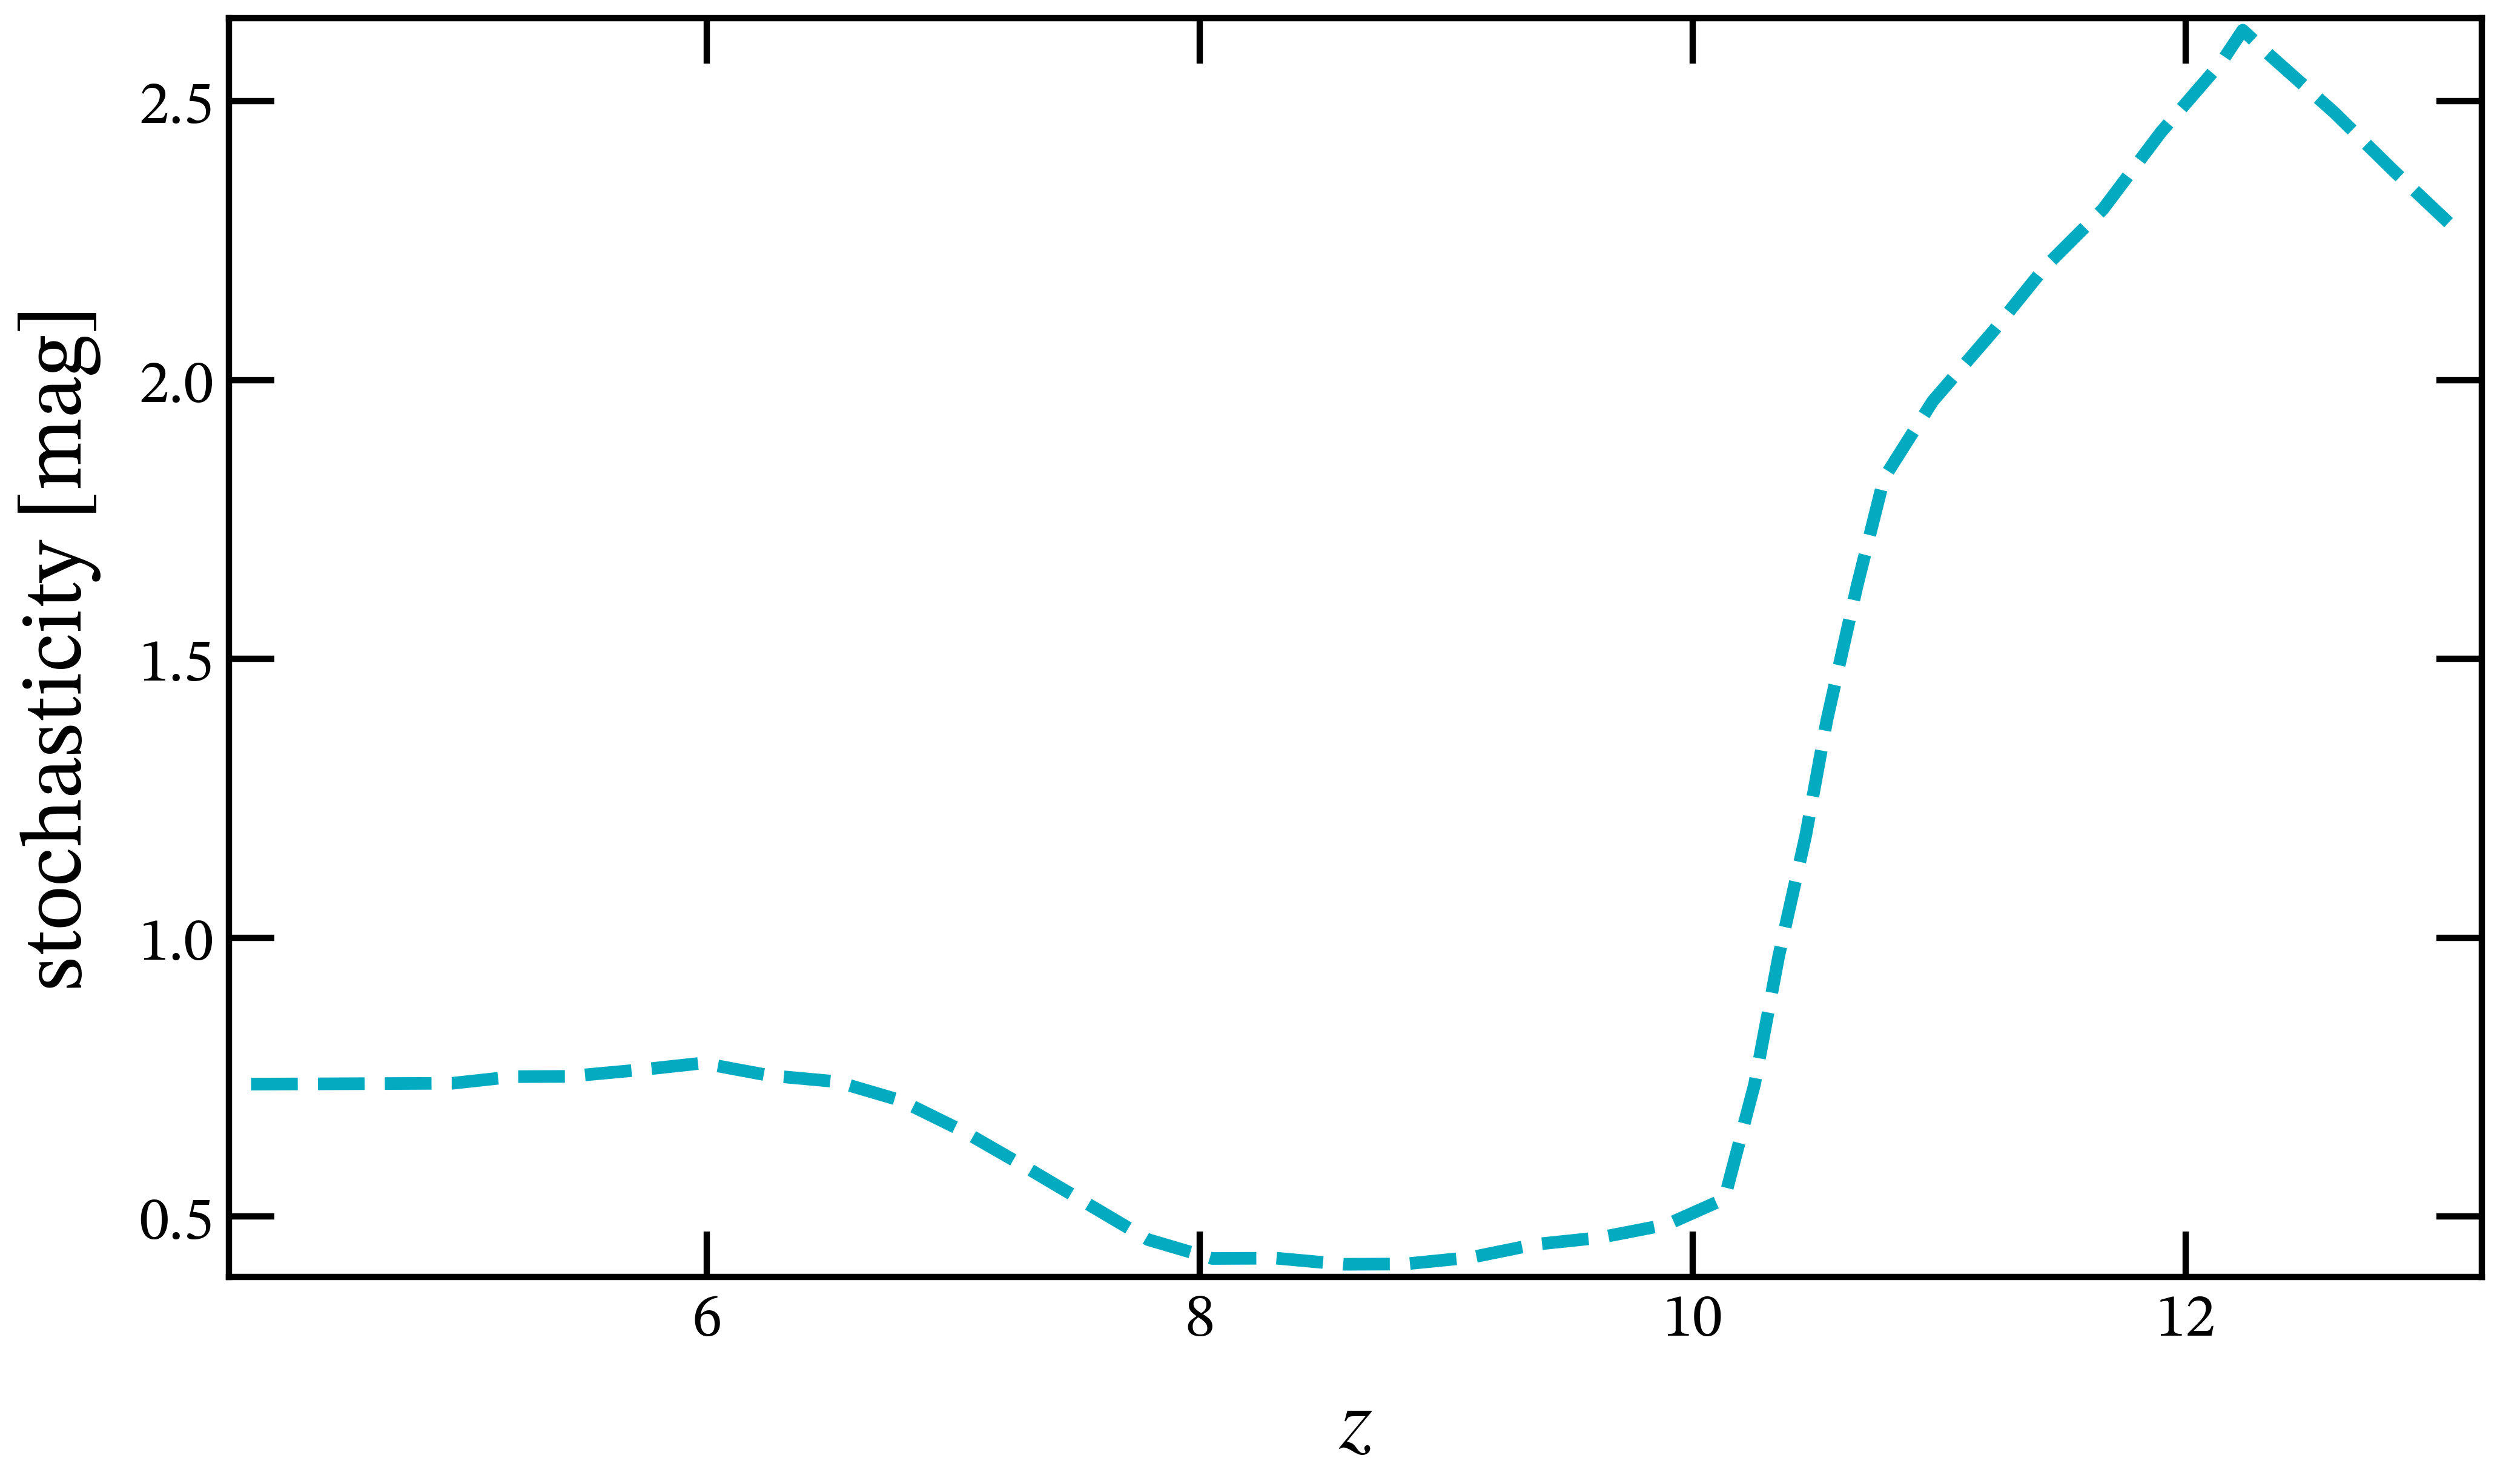

In [83]:
fig, ax = plt.subplots()
ax.plot(sigma[:,0], sigma[:,1], color = '#03abc1', linestyle = '--')
ax.set_ylabel(r'stochasticity [mag]')
ax.set_xlabel(r'$z$')

# fig.savefig('/Users/eb35267/Desktop/figures/adapted figures/munoz_sigma(z).png', bbox_inches='tight')

### Iyer+20 Bursty

In [32]:
FIRE_bursty = np.array([0.21875000000000044, -1.9725675675675678,
0.31250000000000044, -1.4859290540540533,
0.40625000000000044, -1.3236148648648642,
0.5000000000000004, -0.820760135135135,
0.5937500000000004, -0.7557432432432432,
0.7187500000000004, -1.1122972972972978,
0.8125000000000004, -0.7067398648648653,
0.9062500000000004, -0.9336148648648646,
1.0625000000000004, -0.7063344594594598,
1.0937500000000004, -0.4306081081081077,
1.2187500000000004, -0.625,
1.3125000000000004, -0.3816047297297298,
1.40625, -0.39766891891891865,
1.5, -0.31643581081081074,
1.59375, -0.0892567567567566,
1.65625, -0.33239864864864854,
1.71875, -0.5268918918918919,
1.8125, -0.34836148648648635,
1.875, 0.12201013513513503,
1.90625, 0.4788175675675679,
2, -0.12103040540540544,
2.09375, 0.07371621621621616,
2.1875, 0.1549493243243245,
2.3125, 0.39839527027027,
2.40625, 0.17152027027027028,
2.5, 0.6095101351351357,
2.59375, 0.7393918918918923,
2.6875, -0.39559121621621607,
2.8125, 0.3181250000000002,
2.90625, 0.13989864864864865,
3.03125, 0.25361486486486484,
3.09375, 0.38344594594594605,
3.21875, 0.23770270270270233,
3.3125, 0.7243412162162164,
3.40625, 0.059628378378378866,
3.5, 0.17329391891891888,
3.59375, 0.38425675675675697,
3.71875, 0.15743243243243255,
3.8125, 0.2873141891891895,
3.875, 0.3522804054054056,
4, 0.38491554054054067,
4.09375, 0.36885135135135094,
4.21875, 0.40148648648648644,
4.3125, 0.7259628378378378,
4.5, 0.09383445945946,
4.59375, 0.4669594594594595,
4.71875, 0.48337837837837894,
4.78125, 0.48347972972972997,
4.90625, 0.9863851351351354,
5, 0.09464527027027048,
5.09375, 0.7758783783783789,
5.187499999999999, 0.3057601351351349,
5.312499999999999, 0.8735304054054058,
5.406249999999999, -0.09929054054054065,
5.499999999999999, 0.6630236486486489,
5.593749999999999, -0.2935810810810806,
5.812499999999999, 0.5662331081081082,
5.906249999999999, 0.6798986486486487,
5.999999999999999, -0.09832770270270252,
6.093749999999999, 0.5180405405405404,
6.218749999999999, 0.5668918918918919,
6.312499999999999, 0.9238006756756758,
6.406249999999999, 0.5023310810810808,
6.499999999999999, 0.6159966216216222,
6.593749999999999, 0.22695945945945972,
6.687499999999999, 0.4703547297297299,
6.781249999999999, 0.4218581081081081,
6.906249999999999, 0.40584459459459454,
6.968749999999999, 0.7140540540540541,
7.093749999999999, 0.7629054054054056,
7.187499999999999, 0.3252195945945946,
7.281249999999999, 0.6496959459459464,
7.406249999999999, 0.3093581081081078,
7.499999999999999, 0.877077702702703,
7.593749999999999, 0.06641891891891927,
7.687499999999999, 0.601706081081081,
7.812499999999999, 0.4559628378378382,
7.968749999999999, 0.9102702702702707,
8.09375, 0.16452702702702693,
8.21875, 0.9917567567567569,
8.281249999999996, 0.3107770270270267,
8.406249999999996, 0.31097972972972965,
8.5, 0.6841047297297296,
8.59375, 0.4247972972972973,
8.6875, 0.6033277027027029,
8.781249999999996, 0.7332094594594594,
8.906249999999996, 0.4577364864864868,
9, 0.5551858108108108,
9.09375, 0.7499324324324328,
9.1875, 1.009543918918919,
9.281249999999996, 0.620506756756757,
9.406249999999996, 0.5071959459459454,
9.5, 0.8154560810810811,
9.59375, 0.6534459459459465,
9.6875, 0.9779222972972974,
9.781249999999996, 0.5888851351351354,
9.906249999999996, 0.670168918918919,
10, 0.24869932432432407,
10.0625, 0.6866385135135133,
10.09375, 0.9461486486486486,
10.281249999999996, 0.3140202702702699,
10.406249999999996, 0.7520608108108111,
10.5, 0.6549155405405407,
10.59375, 0.7361486486486486,
10.6875, 0.42819256756756774,
10.781249999999996, 0.8337500000000002,
10.875, 0.7366047297297298,
11, 0.7530236486486488,
11.09375, 0.8018243243243246,
11.1875, 0.6884628378378377,
11.281249999999996, 0.8183445945945946,
11.375, 0.8347128378378379,
11.46875, 0.77,
11.59375, 0.7702027027027025,
11.6875, 0.8514358108108109,
11.781249999999996, 0.7380743243243244,
11.906249999999996, 0.7707094594594595,
11.96875, 0.8518918918918921,
12.125, 0.7872804054054057,
12.1875, 0.8035979729729732,
12.3125, 0.7713682432432432,
12.4375, 0.7715709459459461,
12.59375, 0.8042567567567569,
12.6875, 0.7557601351351355,
12.781249999999996, 0.7883445945945948,
12.874999999999996, 0.7560641891891895,
13.062499999999996, 0.740152027027027,
13.187499999999996, 0.772787162162162,
13.312499999999996, 0.7243412162162164,
13.406249999999996, 0.6758445945945946,
13.437499999999996, 0.7083277027027028]).reshape(-1,2)

Illustris = np.array([0.3335033146353905, -1.9729729729729728,
0.36681964983851856, -1.794594594594595,
0.46591874893761753, -1.3405405405405402,
0.49957504674485875, -1.1297297297297293,
0.5962944076151633, -0.9027027027027028,
0.6612272650008508, -0.7081081081081084,
0.9167091619921814, -0.33513513513513526,
1.1069182389937113, -0.18918918918918948,
1.518612952575217, 0.08648648648648649,
2.118816930137685, 0.34594594594594597,
2.2447730749617545, 0.362162162162162,
2.3081761006289305, 0.4108108108108106,
2.9070202277749457, 0.5405405405405403,
3.2218255991840907, 0.5729729729729729,
3.410674825769166, 0.5891891891891889,
3.6624171341152483, 0.6054054054054054,
3.8512663607003237, 0.6216216216216215,
3.9144994050654436, 0.654054054054054,
4.008499065102838, 0.6216216216216215,
4.102838687744349, 0.6216216216216215,
4.197348291687915, 0.6378378378378375,
4.323134455209927, 0.6378378378378375,
4.669046404895463, 0.6378378378378375,
4.889172191058984, 0.6378378378378375,
5.172191058983513, 0.6378378378378375,
5.423763386027537, 0.6378378378378375,
5.612612612612613, 0.654054054054054,
5.832568417474079, 0.6378378378378375,
5.927078021417644, 0.654054054054054,
6.021247662757098, 0.6378378378378375,
6.115757266700664, 0.654054054054054,
6.209926908040117, 0.6378378378378375,
6.335883052864185, 0.654054054054054,
6.870134285228625, 0.6216216216216215,
7.058813530511644, 0.6216216216216215,
7.341662417134117, 0.6054054054054054,
7.436172021077681, 0.6216216216216215,
7.530341662417134, 0.6054054054054054,
7.687744348121706, 0.6216216216216215,
7.8135305116437195, 0.6216216216216215,
7.907870134285227, 0.6216216216216215,
8.065102838687745, 0.6216216216216215,
8.159272480027196, 0.6054054054054054,
8.28505864354921, 0.6054054054054054,
8.379568247492776, 0.6216216216216215,
8.505184429712733, 0.6054054054054054,
8.6311405745368, 0.6216216216216215,
8.725310215876254, 0.6054054054054054,
8.88254292027877, 0.6054054054054054,
9.102498725140237, 0.5891891891891889,
9.385517593064764, 0.5891891891891889,
9.7314295427503, 0.5891891891891889,
10.171851096379399, 0.6054054054054054,
10.234404215536292, 0.5729729729729729,
10.29763725990141, 0.6054054054054054,
10.454530001699814, 0.5729729729729729,
10.674655787863335, 0.5729729729729729,
10.863505014448412, 0.5891891891891889,
10.989121196668368, 0.5729729729729729,
11.11490736019038, 0.5729729729729729,
11.30341662417134, 0.5567567567567564,
11.554988951215366, 0.5567567567567564,
11.64915859255482, 0.5405405405405403,
11.743668196498387, 0.5567567567567564,
11.837837837837839, 0.5405405405405403,
12.278089410164881, 0.5405405405405403,
12.498215196328404, 0.5405405405405403,
12.718340982491927, 0.5405405405405403,
12.875403705592387, 0.5243243243243239,
13.22131565527792, 0.5243243243243239,
13.283868774434811, 0.4918918918918913,
13.31565527791943, 0.5243243243243239,
13.598334183239842, 0.4918918918918913]).reshape(-1,2)

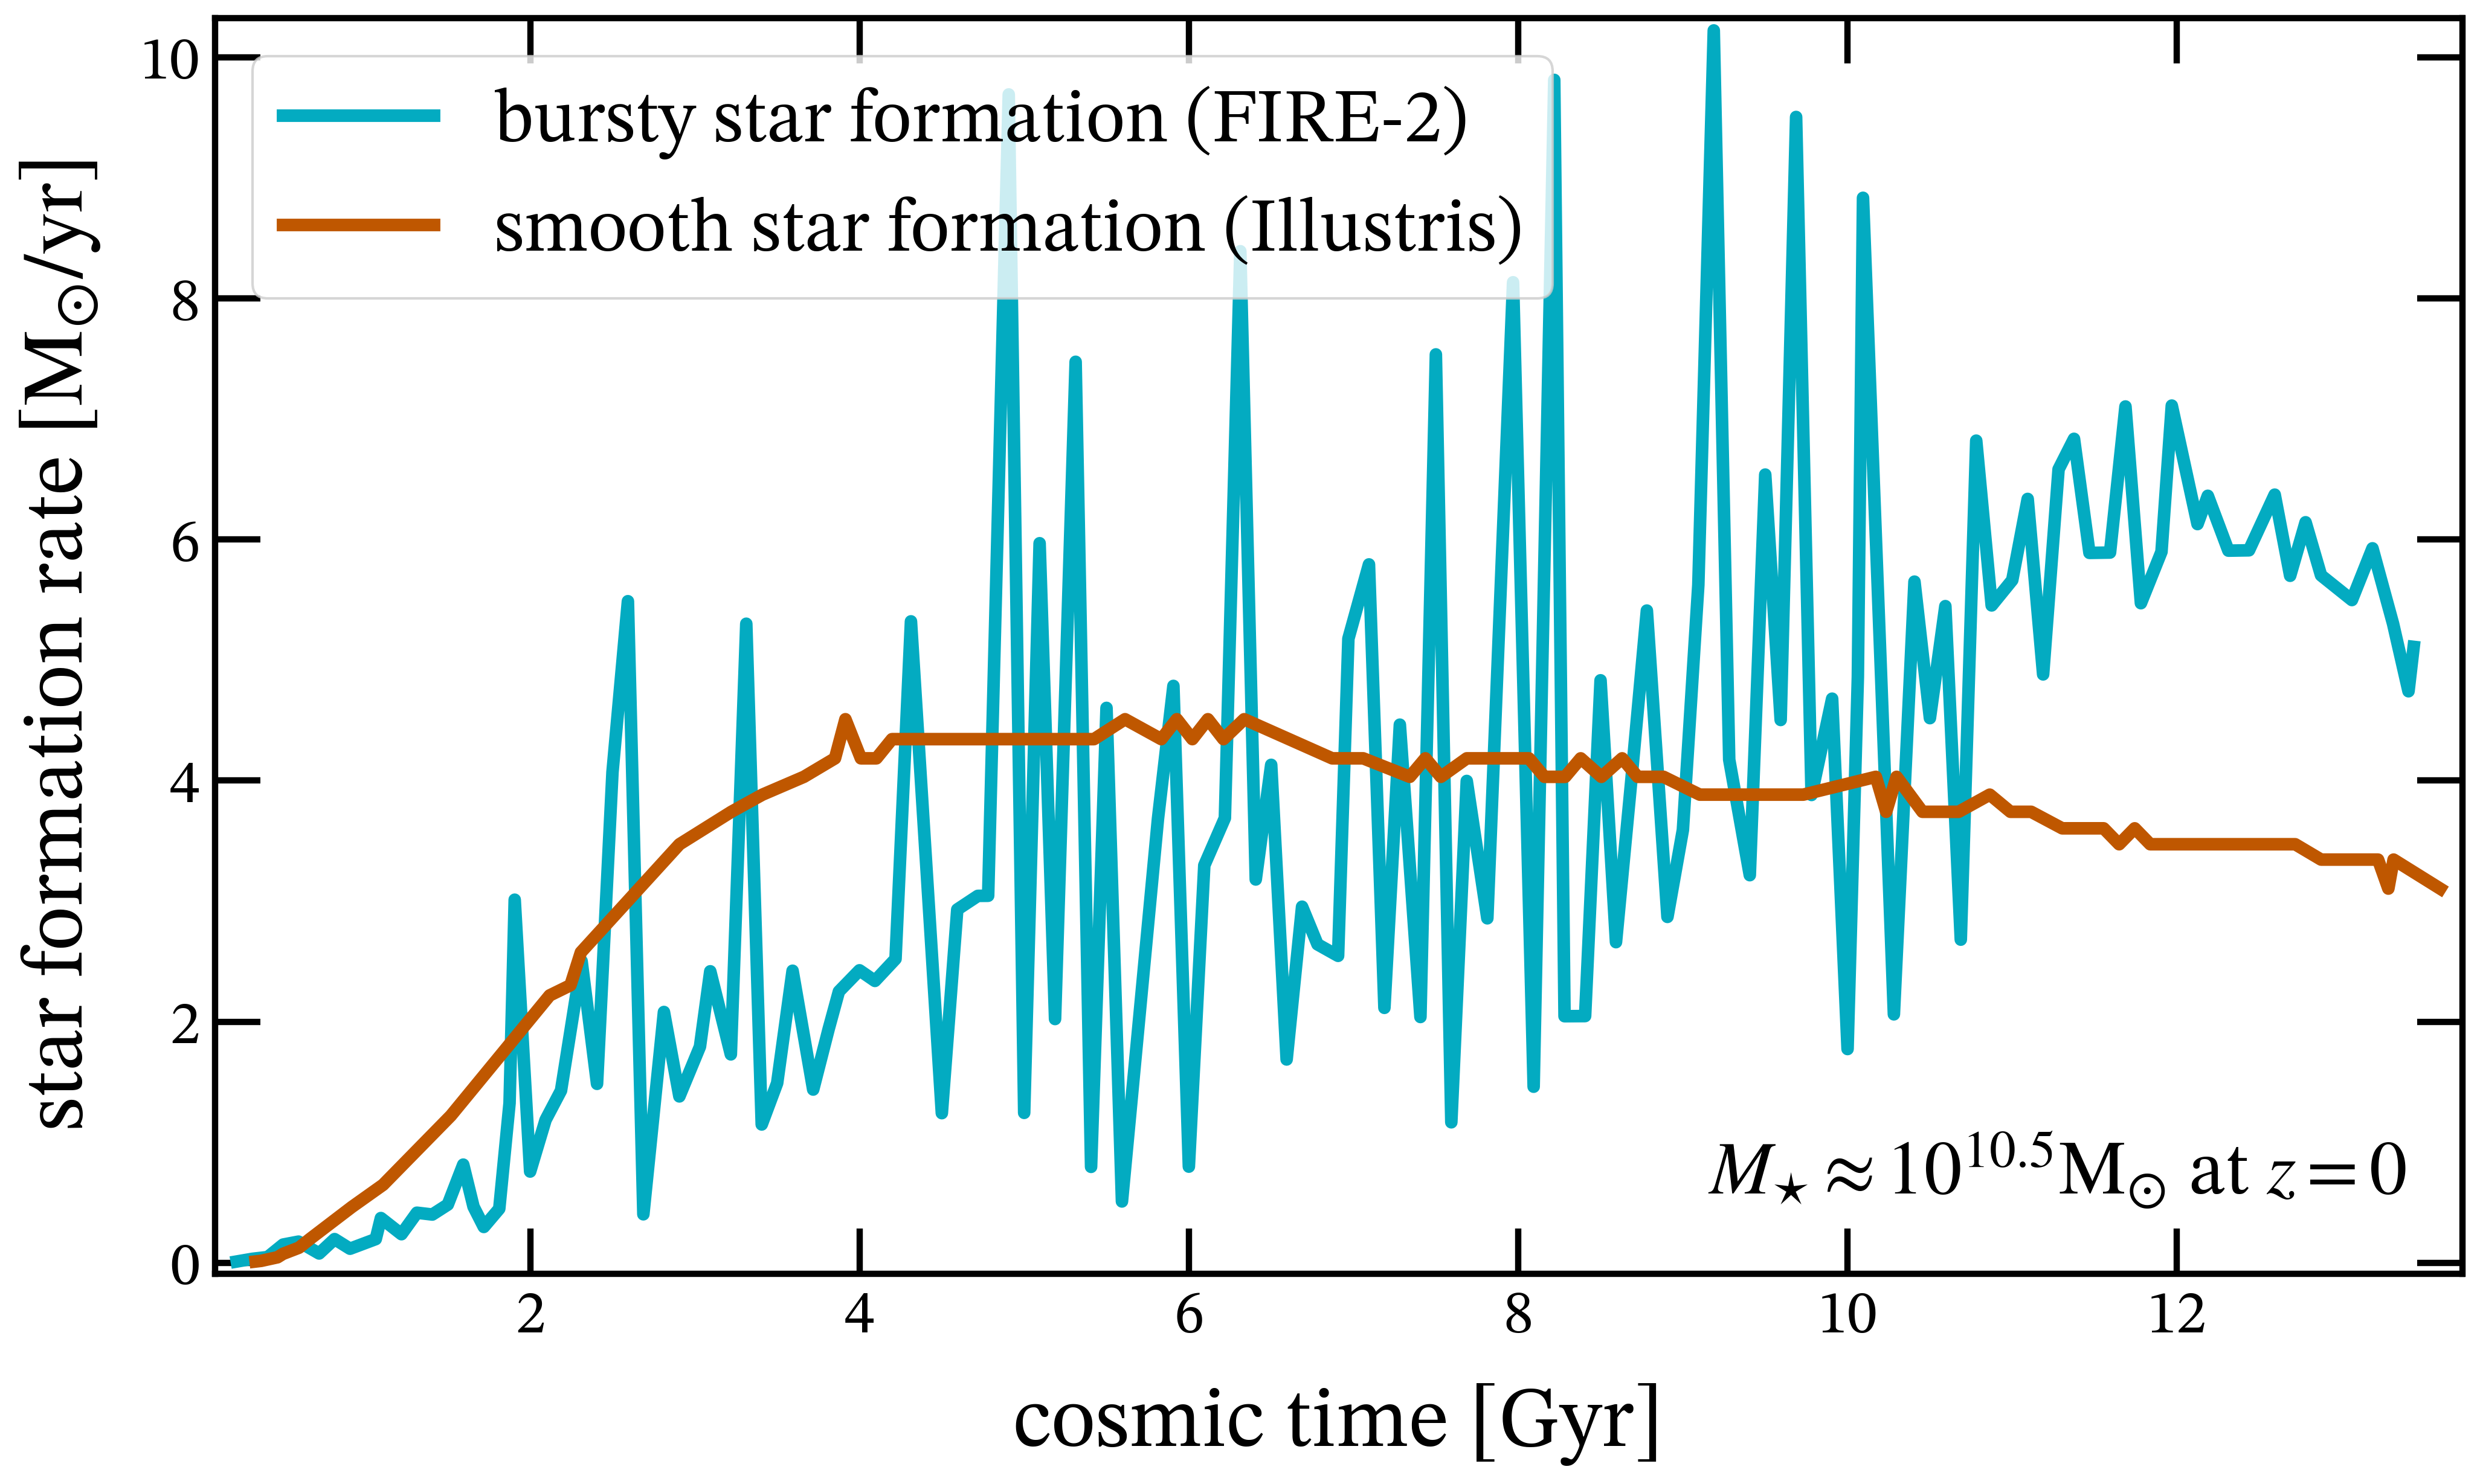

In [68]:
fig, ax = plt.subplots()
ax.plot(FIRE_bursty[:,0], 10**FIRE_bursty[:,1], label = 'bursty star formation (FIRE-2)', color ='#03abc1')
ax.plot(Illustris[:,0], 10**Illustris[:,1], label = 'smooth star formation (Illustris)', color = '#bf5700')
ax.legend()
ax.set_ylabel(r'star formation rate [$\rm{M}_{\odot} / \rm{yr}$]')
ax.set_xlabel('cosmic time [Gyr]')
plt.text(0.975, 0.05, r'$M_{\star} \approx 10^{10.5}\rm{M}_{\odot}$ at $z = 0$', transform=plt.gca().transAxes, verticalalignment='bottom', 
         horizontalalignment='right')

#fig.savefig('/Users/eb35267/Desktop/figures/adapted figures/bursty_Iyer.png', bbox_inches = 'tight')